In [1]:
%pip install -q otter-grader

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.5/145.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.6/101.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.2/119.2 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.1/88.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.2/48.2 MB 8.4 MB/s eta 0:00:00


# In-Class Exercise 03: $k$-Means Clustering

**DS701 — Session 4 (Wed Sep 16, 2026) — Section A1**

[![](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tools4ds/DS701-Materials-FA26/blob/main/class_activity_notebooks/03-InClass-Exercise-Clustering-A1/03-InClass-Exercise-Clustering-A1.ipynb)

**Time: ~60 minutes.** Work in groups of 2-3.

Parts marked **(autograded)** are submitted to Gradescope; open-ended parts are graded
for participation. You may use AI assistance, but you must be able to explain and
justify every part of your solution when asked. Staff will circulate and ask.

**Plan**

| Part | Topic | Grading | Time |
|---|---|---|---|
| 1 | One Lloyd's iteration, by hand | autograded | ~15 min |
| 2 | Run to convergence, compare with `sklearn` | autograded | ~10 min |
| 3 | **Stretch:** choosing $k$ — the elbow method, and when it is ambiguous | partly autograded | ~15 min |
| 4 | Breaking $k$-means | participation | ~15 min |

Dependencies: `numpy`, `matplotlib`, `scikit-learn`.

## Setup

We use a small synthetic dataset: 300 points in $\mathbb{R}^2$ drawn from 4 fairly
well-separated Gaussian blobs. `y_true` is the blob each point came from — we will
*only* use it at the very end to sanity-check, never to fit. Clustering is
unsupervised.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

In [3]:
# Lecture section. Only A1 runs this semester; this is kept because the build
# script reads it to name the variant directory the notebook is published in.
SECTION = "A1"
SEED = 701
RANDOM_STATE = SEED
print(f"You are working on the {SECTION} variant (seed {SEED}).")


You are working on the A1 variant (seed 701).


In [4]:
# Colab: fetch the autograder tests for this activity.
import os, sys, urllib.request

if "google.colab" in sys.modules:
    os.makedirs("tests", exist_ok=True)
    BASE = "https://raw.githubusercontent.com/tools4ds/DS701-Materials-FA26/main/class_activity_notebooks/03-InClass-Exercise-Clustering-A1/tests/"
    for _q in ("q1", "q2", "q3", "q4"):
        urllib.request.urlretrieve(BASE + _q + ".py", "tests/" + _q + ".py")

In [5]:
# Initialize Otter
import otter
grader = otter.Notebook()

X.shape = (300, 2)


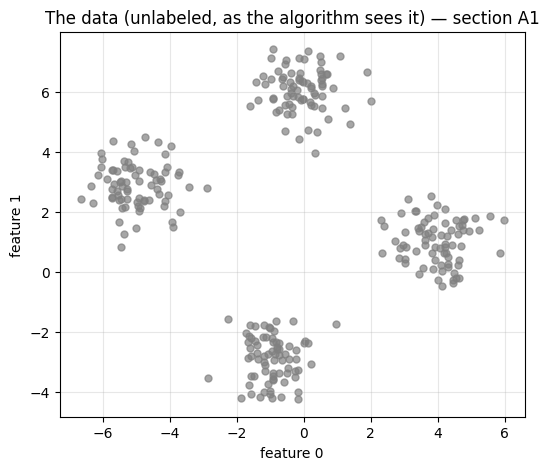

In [6]:
# Create fairly tightly clustered well separated blobs
BLOB_CENTERS = np.array([[-5.0, 3.0], [0.0, 6.0], [4.0, 1.0], [-1.0, -3.0]])

X, y_true = make_blobs(
    n_samples=300, centers=BLOB_CENTERS, cluster_std=0.70, random_state=RANDOM_STATE
)

print("X.shape =", X.shape)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], s=25, alpha=0.7, c="gray")
plt.title(f"The data (unlabeled, as the algorithm sees it) — section {SECTION}")
plt.xlabel("feature 0")
plt.ylabel("feature 1")
plt.grid(alpha=0.3)
plt.show()


In [7]:
# A fixed, deliberately arbitrary initialization: k random data points. Everyone
# in your section starts from the same centers so results are comparable (and
# gradeable). The seed offset is chosen so this particular start converges in a
# handful of iterations -- bad starts are the recap's topic, not this Part's.
k = 4
rng = np.random.default_rng(RANDOM_STATE + 3)
init_centroids = X[rng.choice(len(X), k, replace=False)]
print("initial centroids:\n", np.round(init_centroids, 3))


initial centroids:
 [[-5.452  0.814]
 [-5.694  4.367]
 [ 0.123 -2.393]
 [-1.191 -2.808]]


## Part 1 (autograded): one Lloyd's iteration, by hand

Recall the algorithm:

1. pick $K$ centers $\{c_1,\dots,c_K\}$,
2. **assign** each point to the cluster with the closest center,
3. **update** each center to the center of mass of its cluster,
4. repeat 2-3 until convergence.

and the objective it is trying to minimize, the Within-Cluster Sum of Squares:

$$\text{WCSS} = \sum_{j=1}^{K}\ \sum_{x \in C_j} \lVert x - c_j \rVert^2 .$$

**Task.** Implement the three building blocks below with `numpy`. Do **not** call
`sklearn` here — the point is to know exactly what the library is doing.

- `assign_clusters(X, centroids)` → integer array of shape `(n,)`, entry $i$ is the
  index of the centroid nearest to `X[i]` (Euclidean distance).
- `update_centroids(X, labels, k)` → array of shape `(k, d)`, row $j$ is the mean of
  the points labeled $j$.
- `compute_wcss(X, labels, centroids)` → a single float, the WCSS.


### Hints and Tips

All three can be written without a single `for` loop over the $n$ data points — let
**broadcasting** do the looping. It is worth the effort: the vectorized version is
what `sklearn` actually does, and it is the difference between milliseconds and
seconds once $n$ gets large.

> See [NumPy Broadcasting Basics](https://numpy.org/doc/stable/user/basics.broadcasting.html) for a good overview.

**The one rule.** NumPy lines up the shapes of two arrays **from the right**. A pair
of dimensions is compatible if they are equal, or if one of them is 1 — and a
dimension of size 1 is *stretched* (without copying) to match the other. So
`(n, 1, d)` and `(1, k, d)` combine to `(n, k, d)`: every one of the $n$ points is
paired with every one of the $k$ centroids, all at once.

You create those length-1 dimensions yourself with `np.newaxis` (or its alias
`None`) inside the index brackets — e.g. `A[:, np.newaxis, :]` turns a `(n, d)`
array into `(n, 1, d)`. Nothing is copied; NumPy just reinterprets the strides.

**Debugging tip.** When a broadcast misbehaves, print `.shape` after every step and
check it against the shape you *expect*. Almost every broadcasting bug is a
length-1 axis in the wrong position — and the dangerous ones are the bugs that
still produce an array of a plausible shape, silently pairing the wrong things.

---

**`assign_clusters(X, centroids)`**

- `X` is `(n, d)`, `centroids` is `(k, d)`. You want the full table of distances from
  every point to every centroid — that table is `(n, k)`. Getting there in one
  expression means first forming the `(n, k, d)` array of *coordinate differences*,
  so add a length-1 axis to each operand as above: which axis goes where is decided
  by wanting rows = points and columns = centroids.
- Collapse the last axis (the $d$ coordinates) to turn differences into distances.
  Both `np.linalg.norm` and "square, `np.sum`, `np.sqrt`" take an `axis=` argument —
  pass the axis you want to *disappear*.
- Then reduce the `(n, k)` table to `(n,)` with `np.argmin`, again choosing the
  `axis=` so that the result has one entry per point. (Sanity check: if you get an
  answer of length $k$ instead of $n$, you reduced the wrong axis.)
- Micro-optimization worth knowing: $\sqrt{\cdot}$ is monotone, so the nearest
  centroid by *squared* distance is the same one as by distance. You can skip the
  square root here — but **not** in `compute_wcss`, where the actual value matters.

**`update_centroids(X, labels, k)`**

- A different broadcast, this time a comparison: `labels == j` broadcasts the scalar
  `j` against the whole `(n,)` array and gives you an `(n,)` array of booleans. Used
  as an index, that mask selects exactly the rows of `X` belonging to cluster $j$ —
  no loop over points needed.
- On that selected block, `.mean(axis=0)` averages *down the rows*, leaving one value
  per feature — a `(d,)` centroid.
- Here a short loop over the $k$ clusters is fine and readable ($k$ is tiny, $n$ is
  not). Collect the $k$ results and stack them into the required `(k, d)` array —
  `np.array([...])` on a list of `(d,)` rows does this. Whatever you do, make sure
  the row order is $j = 0, 1, \dots, k-1$, since the row index *is* the cluster
  label.

**`compute_wcss(X, labels, centroids)`**

- Reuse the same mask idea. Subtracting `centroids[j]`, shape `(d,)`, from a block
  of shape `(m, d)` broadcasts the centroid against every one of the $m$ rows — the
  `(d,)` is right-aligned against the trailing axis and the leading axis is
  stretched. That is the whole "distance of each point from its own center" step, in
  one subtraction.
- Square the result and sum over *both* axes (a bare `.sum()` with no `axis=`
  collapses everything) to get that cluster's contribution; add up the $k$
  contributions. Note there is **no square root** in the WCSS formula — the objective
  is a sum of *squared* distances.
- The tests check `isinstance(..., float)`, so wrap the total in `float(...)`: NumPy
  reductions hand back a `np.float64` scalar, not a Python `float`.

In [66]:
def assign_clusters(X, centroids):
    """Return the index of the nearest centroid for each row of X."""
    # X shape: (n, d) -> (n, 1, d)
    # centroids shape: (k, d) -> (1, k, d)
    # Resulting broadcasted shape for subtraction: (n, k, d)
    differences = X[:, np.newaxis, :] - centroids[np.newaxis, :, :]
    # Calculate squared Euclidean distance. sum along the last axis (d) to get (n, k)
    squared_distances = np.sum(differences**2, axis=-1)
    # Find the index of the minimum distance for each point (along axis 1, k)
    return np.argmin(squared_distances, axis=1)

def update_centroids(X, labels, k):
    """Return the (k, d) array of cluster means."""
    centroid_averages = []
    for label in range(k):
      mask = labels == label
      cluster_points = X[mask]
      average = cluster_points.mean(axis=0)
      centroid_averages.append(average)
    return np.array(centroid_averages)


def compute_wcss(X, labels, centroids):
    """Return the within-cluster sum of squared distances to the assigned center."""
    wcss = 0
    k = len(centroids)
    for j in range(k):
      cluster_points = X[labels == j]
      wcss += np.sum((cluster_points - centroids[j]) ** 2)
    return np.float64(wcss)

### Part 1b (autograded): run exactly one iteration

Starting from `init_centroids`, do **one** assignment step and **one** update step.
Store:

- `labels_1` — the assignment produced by the first assignment step,
- `centroids_1` — the centers after the first update step,
- `wcss_before` — WCSS of `labels_1` with the **old** centers `init_centroids`,
- `wcss_after` — WCSS of `labels_1` with the **new** centers `centroids_1`.

Then answer, in the markdown cell that follows: *why must `wcss_after` be no larger
than `wcss_before`, no matter what the data is?*


WCSS before update: 4965.14
WCSS after  update: 1499.99


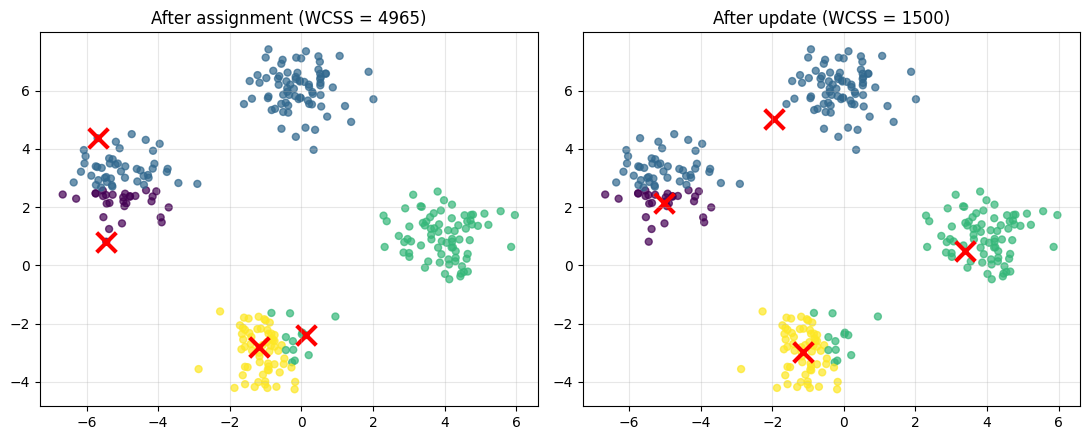

In [68]:
labels_1 = assign_clusters(X,init_centroids)
wcss_before = compute_wcss(X,labels_1,init_centroids)

centroids_1 = update_centroids(X,labels_1,k)
wcss_after = compute_wcss(X,labels_1,centroids_1)

print(f"WCSS before update: {wcss_before:.2f}")
print(f"WCSS after  update: {wcss_after:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, cents, title in [
    (axes[0], init_centroids, f"After assignment (WCSS = {wcss_before:.0f})"),
    (axes[1], centroids_1, f"After update (WCSS = {wcss_after:.0f})"),
]:
    ax.scatter(X[:, 0], X[:, 1], c=labels_1, cmap="viridis", s=25, alpha=0.7)
    ax.scatter(cents[:, 0], cents[:, 1], c="red", marker="x", s=200, linewidths=3)
    ax.set_title(title)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Your answer (why can't WCSS go up?):**

*(write 1-2 sentences here)*


In [69]:
grader.check("q1")

q1 results: All test cases passed!

## Part 2 (autograded): run to convergence and compare with `scikit-learn`

**Task.** Loop your Part 1 functions until the centers stop moving, then check yourself
against the library.

1. Write `my_kmeans(X, init_centroids, k, max_iter=100, tol=1e-8)` returning
   `(centroids, labels, wcss, n_iter)`. Stop when every center moves less than `tol`
   (or after `max_iter` passes). Remember to re-assign after the final update so the
   labels match the returned centers.
2. Fit [`sklearn.cluster.KMeans`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) from the **same** starting point:
   `KMeans(n_clusters=k, init=init_centroids, n_init=1, random_state=RANDOM_STATE)`.
   Store it in `km`.
3. Compare `my_wcss` against `km.inertia_`.

Passing `init=init_centroids, n_init=1` disables `sklearn`'s $k$-means++ and its
multiple restarts — so it runs the *same* algorithm from the *same* place as you.


In [75]:
import sklearn

In [77]:
def my_kmeans(X, init_centroids, k, max_iter=100, tol=1e-8):
    """Run Lloyd's algorithm to convergence. Returns (centroids, labels, wcss, n_iter)."""
    current_centroids = init_centroids
    n_iter = 0

    for iteration in range(max_iter):
        labels = assign_clusters(X, current_centroids)
        updated_centroids = update_centroids(X, labels, k)

        # Check for convergence using np.allclose for robust floating-point comparison
        if np.allclose(current_centroids, updated_centroids, atol=tol):
            n_iter = iteration + 1
            # Recalculate labels and wcss one last time with the converged centroids
            final_labels = assign_clusters(X, updated_centroids)
            final_wcss = compute_wcss(X, final_labels, updated_centroids)
            return updated_centroids, final_labels, final_wcss, n_iter

        current_centroids = updated_centroids
        n_iter = iteration + 1 # Update n_iter for early convergence or if max_iter is reached

    # If the loop finishes without convergence (i.e., max_iter reached)
    # Return the last computed values
    final_labels = assign_clusters(X, current_centroids)
    final_wcss = compute_wcss(X, final_labels, current_centroids)
    return current_centroids, final_labels, final_wcss, n_iter


my_centroids, my_labels, my_wcss, my_iters = my_kmeans(X, init_centroids, k)
print(f"mine:    WCSS = {my_wcss:.4f} after {my_iters} iterations")

km = KMeans(n_clusters=k, init=init_centroids, n_init=1, random_state=RANDOM_STATE)
km.fit(X) # Fit the KMeans model to the data
print(f"sklearn: WCSS = {km.inertia_:.4f} after {km.n_iter_} iterations")

mine:    WCSS = 309.7901 after 4 iterations
sklearn: WCSS = 309.7901 after 4 iterations


In [78]:
grader.check("q2")

q2 results: All test cases passed!

Sanity check the result visually, and (only now, only to look) against the blobs the
data actually came from.


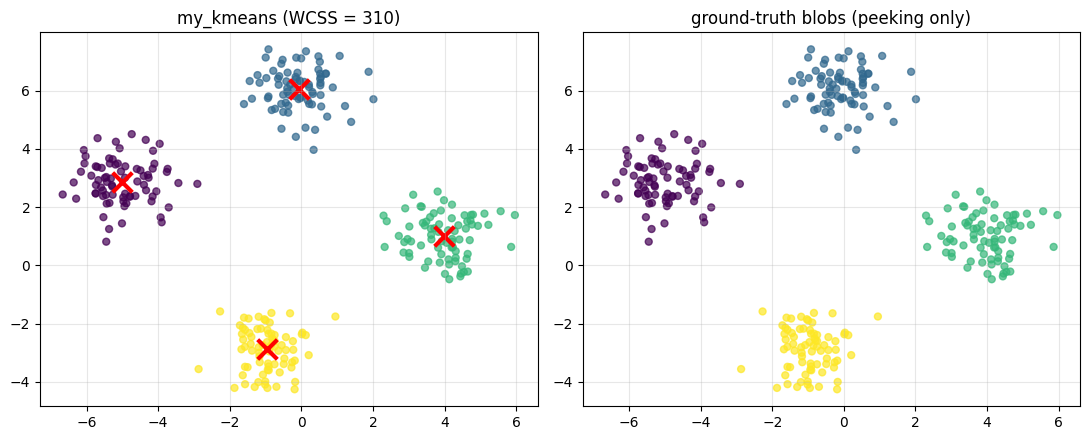

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(X[:, 0], X[:, 1], c=my_labels, cmap="viridis", s=25, alpha=0.7)
axes[0].scatter(my_centroids[:, 0], my_centroids[:, 1], c="red", marker="x",
                s=200, linewidths=3)
axes[0].set_title(f"my_kmeans (WCSS = {my_wcss:.0f})")
axes[1].scatter(X[:, 0], X[:, 1], c=y_true, cmap="viridis", s=25, alpha=0.7)
axes[1].set_title("ground-truth blobs (peeking only)")
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Part 3 — Stretch: choosing $k$

In Parts 1 and 2 we were handed $k = 4$. In practice $k$ is a **hyperparameter** and
nobody hands it to us. The standard first tool is the **elbow method**: plot WCSS
against $k$ and look for the bend where extra clusters stop buying much.

The catch is that WCSS decreases monotonically in $k$ — it hits 0 at $k = n$, one
cluster per point — so the *minimum* is useless and only the **shape** of the curve
carries information. Below you build the sweep, turn "look for the bend" into a rule a
computer can apply, and then meet a dataset where the bend is not where your eye first
puts it.

### Part 3a (autograded): sweep $k$ and find the elbow

**Task.**

1. Write `sweep_k(X, k_max=10)` that fits
   `KMeans(n_clusters=kk, n_init=10, random_state=RANDOM_STATE)` for every `kk` in
   `1..k_max` and returns `wcss_by_k`, the list of inertias for $k = 1, \dots, k_{\max}$
   (length `k_max`).
2. "Look for the bend" is not something you can hand to a computer, so make it precise.
   Write `elbow_k(wcss, threshold=0.20)` returning the **smallest** $k$ whose
   *relative* improvement from $k$ to $k+1$,

   $$ r_k = \frac{\text{WCSS}(k) - \text{WCSS}(k+1)}{\text{WCSS}(k)}, $$

   is below `threshold` — i.e. the first $k$ past which one more cluster buys you less
   than 20% of what you have left. Note `wcss[0]` is $k = 1$, so mind the off-by-one
   when you turn an index into a $k$.
3. Run the sweep on `X`, plot it with the `plot_sweep` helper, and set `best_k_elbow`
   to `elbow_k(wcss_by_k)`.

Why *relative* and not absolute? The raw drops shrink as $k$ grows no matter what the
data looks like, so "the drop got small" would fire on any dataset. A ratio asks the
scale-free question: of the error still on the table, how much does the next cluster
remove?

WCSS:                [6508.7, 3084.7, 1606.1, 309.8, 278.1, 250.6, 219.7, 195.5, 177.8, 156.1]
relative drop k->k+1: [0.526, 0.479, 0.807, 0.102, 0.099, 0.123, 0.11, 0.091, 0.122]
best k by the elbow rule: 4


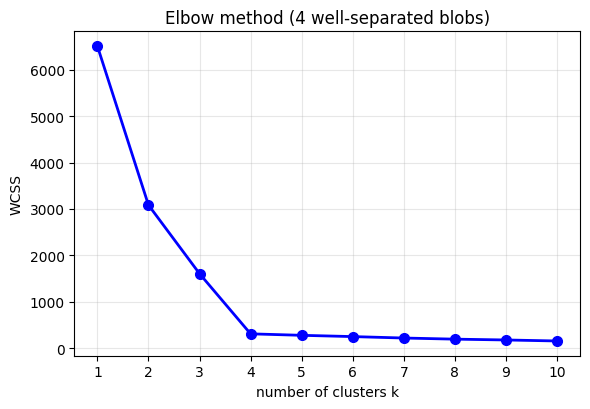

In [84]:
def sweep_k(X, k_max=10):
    """Return wcss_by_k, the KMeans inertia for k = 1..k_max."""
    wcss_by_k = []
    for label in range(k_max):
      km = KMeans(n_clusters=label+1, n_init=10, random_state=RANDOM_STATE)
      km.fit(X)
      wcss_by_k.append(km.inertia_)
    return wcss_by_k


def elbow_k(wcss, threshold=0.20):
    """Smallest k whose relative improvement to k+1 falls below `threshold`."""
    for index in range(len(wcss)-1):
      relative_drop = (wcss[index] - wcss[index+1])/wcss[index]
      if relative_drop < threshold:
        return index+1




def plot_sweep(wcss, title=""):
    """Elbow plot: WCSS against k (helper, nothing to fill in)."""
    fig, ax = plt.subplots(figsize=(6, 4.2))
    ax.plot(range(1, len(wcss) + 1), wcss, "bo-", linewidth=2, markersize=7)
    ax.set_xlabel("number of clusters k")
    ax.set_ylabel("WCSS")
    ax.set_title("Elbow method " + title)
    ax.set_xticks(range(1, len(wcss) + 1))
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


k_range = list(range(1, 11))

wcss_by_k = sweep_k(X)
best_k_elbow = elbow_k(wcss_by_k)

print("WCSS:               ", [round(v, 1) for v in wcss_by_k])
print("relative drop k->k+1:",
      [round((wcss_by_k[i] - wcss_by_k[i + 1]) / wcss_by_k[i], 3) for i in range(9)])
print("best k by the elbow rule:", best_k_elbow)

plot_sweep(wcss_by_k, "(4 well-separated blobs)")

**Discuss (participation, 1-2 sentences each):**

1. Where is the elbow in the WCSS plot? Is it as obvious as the textbook picture?
2. WCSS at $k = 10$ is much lower than at $k = 4$. Why is that not an argument for
   $k = 10$?
3. `elbow_k` has a `threshold` knob. What would you have to know to choose it — and
   what does that say about how automatic the "automatic" elbow really is?

*(your answers here)*

In [ ]:
grader.check("q3")

### Part 3b (autograded + discussion): when the elbow is in the eye of the beholder

The blobs above were the friendly case: the bend is unmistakable and it is the truth.
Now a dataset built to be awkward: **three** Gaussian blobs, but two of them are close
neighbors and the third is far away. (Your section's geometry differs from the other
section's.)

**Task.** Run the cell that makes `X_hard`, then use your `sweep_k` to fill
`wcss_hard_by_k`, plot it with `plot_sweep`, and set `best_k_elbow_hard` to the rule's
choice of $k$. **Before you look at the rule's answer, write down the $k$ you would
have picked by eye from the plot** — you will need it in a moment.

In [ ]:
HARD_CENTERS = np.array([[0.0, 0.0], [3.0, 0.0], [10.0, 0.0]])

X_hard, y_hard = make_blobs(
    n_samples=300, centers=HARD_CENTERS, cluster_std=1.0, random_state=RANDOM_STATE
)

plt.figure(figsize=(6, 5))
plt.scatter(X_hard[:, 0], X_hard[:, 1], s=25, alpha=0.7, c="gray")
plt.title(f"X_hard, unlabeled — section {SECTION}")
plt.gca().set_aspect("equal")
plt.grid(alpha=0.3)
plt.show()


In [ ]:
wcss_hard_by_k = ...
best_k_elbow_hard = ...

print("WCSS:               ", [round(v, 1) for v in wcss_hard_by_k])
print("relative drop k->k+1:",
      [round((wcss_hard_by_k[i] - wcss_hard_by_k[i + 1]) / wcss_hard_by_k[i], 3)
       for i in range(9)])
print("best k by the elbow rule:", best_k_elbow_hard)

plot_sweep(wcss_hard_by_k, "(X_hard)")

In [ ]:
grader.check("q4")

Most people's eye says **2** on that plot, but `elbow_k` said **3**. Neither is
misreading the numbers — the linear plot is dominated by the enormous drop from $k=1$
to $k=2$, which squashes everything after it into a flat-looking tail. Two standard
moves make the rest of the curve readable: a **log scale** on WCSS (equal vertical
steps = equal *ratios*, which is what the rule is measuring), and simply **looking at
the assignments** for the candidate $k$s. Run the cell below and look before you answer
the next question.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))

axes[0].semilogy(k_range, wcss_hard_by_k, "bo-", linewidth=2, markersize=7)
axes[0].set_xticks(k_range)
axes[0].set_xlabel("number of clusters k")
axes[0].set_ylabel("WCSS (log scale)")
axes[0].set_title("Elbow, log scale")
axes[0].grid(alpha=0.3, which="both")

for ax, kk in zip(axes[1:], (2, 3)):
    m = KMeans(n_clusters=kk, n_init=10, random_state=RANDOM_STATE).fit(X_hard)
    ax.scatter(X_hard[:, 0], X_hard[:, 1], c=m.labels_, cmap="viridis", s=25, alpha=0.9)
    ax.scatter(m.cluster_centers_[:, 0], m.cluster_centers_[:, 1], c="red", marker="x",
               s=200, linewidths=3)
    ax.set_title(f"k = {kk}: the actual partition\n(WCSS = {m.inertia_:.0f})")
    ax.set_aspect("equal")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<!-- BEGIN QUESTION -->

### Part 3b, continued (participation): which $k$, and why?

Your eye said one thing, the rule said another, the log plot probably changed your
mind, and the data were in fact generated from three blobs. Discuss in your group and
write down:

1. **What does the elbow criterion actually reward, and why did the linear plot
   mislead you?** In one sentence each: what is WCSS measuring when it drops from
   $k=1$ to $k=2$ on *this* data, and why does a log axis (or a ratio rule) change
   which bend you see?
2. **Which $k$ would you report, and what would change your mind?** There is no
   single right answer, but "the truth is 3" is not a reason available to someone who
   does not have `y_hard`. Name a concrete downstream use for which 2 is the better
   answer and one for which 3 is.
3. **The general rule.** Finish this sentence: "When the elbow is ambiguous, I
   will …" — and it cannot be "pick the one that agrees with what I expected".

**Be ready to explain your reasoning when staff visit your table** — they will ask
you to point at the plots and walk through *why*, not just which number you chose.

_Type your answer here, replacing this text._

<!-- END QUESTION -->

## Part 4 (open-ended, participation): breaking $k$-means

The blobs above were round, similar size, similar spread. Below is the same generator
followed by a **linear transformation** — the clusters are still Gaussian, just
stretched and rotated (*anisotropic*).

Run the cell, then work through the questions. **Be ready to explain your reasoning when
staff visit** — they will ask groups to walk through *why* the failure happens, not
just that it does.


In [ ]:
transformation = np.array([[0.60834549, -0.63667341], [-0.40887718, 0.85253229]])
X_blobs, y_aniso = make_blobs(n_samples=600, random_state=170)
X_aniso = X_blobs @ transformation

km_aniso = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE).fit(X_aniso)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(X_aniso[:, 0], X_aniso[:, 1], c=y_aniso, cmap="viridis", s=15, alpha=0.7)
axes[0].set_title("Ground truth")
axes[1].scatter(X_aniso[:, 0], X_aniso[:, 1], c=km_aniso.labels_, cmap="viridis",
                s=15, alpha=0.7)
axes[1].scatter(km_aniso.cluster_centers_[:, 0], km_aniso.cluster_centers_[:, 1],
                c="red", marker="x", s=200, linewidths=3)
axes[1].set_title("k-means, k = 3")
for ax in axes:
    ax.set_aspect("equal")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


<!-- BEGIN QUESTION -->

### 4a. Diagnose

$k$-means found 3 clusters and its WCSS is a perfectly good local minimum — yet the
partition is wrong. Write down, in your own words:

- What geometric shape does the boundary between two $k$-means clusters always have,
  and why does that follow directly from the assignment step?
- Which assumption baked into the WCSS objective does this dataset violate?
- Would running more iterations, a better initialization, or a larger `n_init` help
  here? Why or why not?
- *(Connect to Part 3.)* Would the elbow have warned you? Run `sweep_k(X_aniso)` and
  `elbow_k` on it — what $k$ does the rule pick, and what does that tell you about
  using a WCSS-based criterion as a referee for non-spherical clusters?

_Type your answer here, replacing this text._

### 4b. Mitigate

Try at least one fix and report whether it helped. Some directions (pick one, or invent
your own):

- **Rescale.** Feature scaling changes what "distance" means. Try `StandardScaler`
  (each feature to zero mean and unit variance) and re-run $k$-means on the transformed
  data. Look hard at the picture before you predict the result.
- **Change the model.** `sklearn.mixture.GaussianMixture(n_components=3,
  covariance_type="full")` fits an ellipse per cluster instead of a ball — it is
  $k$-means with the spherical assumption removed.
- **Over-cluster and merge.** Run $k$-means with $k = 9$ and see whether the small cells
  respect the true boundaries well enough to be merged.

Use `adjusted_rand_score(y_aniso, labels)` to score each attempt against the truth (1.0
is a perfect match, 0.0 is chance). Plain $k$-means scores about **0.59** here — beat it.

In [ ]:
from sklearn.metrics import adjusted_rand_score

print("plain k-means:   ", round(adjusted_rand_score(y_aniso, km_aniso.labels_), 3))

...

**Your 4b write-up:** which fix did you try, what adjusted Rand index did it reach,
and *why* did it help (or not)?

*(replace this text with your answer)*


<!-- END QUESTION -->

---


### 4c. If you have time

Build your own failure case and diagnose it the same way. Options:

- `make_moons(n_samples=300, noise=0.05)` — two interleaved crescents, $k = 2$.
- `make_blobs(..., cluster_std=[1.0, 2.5, 0.5])` — unequal variance.
- `np.vstack([X[y == 0][:500], X[y == 1][:100], X[y == 2][:10]])` — unequal *sizes*.

For each, predict what $k$-means will do **before** you run it, then check. Which of
these can feature scaling fix, and which are baked into the objective and cannot be?
And for each: would `sweep_k` have pointed you at the right $k$?


In [ ]:
# Scratch space for 4c.


## Wrap-up

Before you leave, each group should be able to answer:

1. Which step of Lloyd's algorithm can increase WCSS? (Trick question.)
2. Why is a lower WCSS not automatically a better clustering?
3. Why does the elbow method look at the *shape* of the WCSS curve rather than its
   minimum, and why did we threshold *relative* improvement rather than absolute?
4. On `X_hard`, why did your eye and the elbow rule disagree — and what did you decide?
5. Name one $k$-means failure mode that feature scaling fixes and one that it does not.

Run your notebook and submit on Gradescope.